In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
train_dir = "/content/drive/MyDrive/5. Movie Review Dataset/train_movie_review.csv"
val_dir   = "/content/drive/MyDrive/5. Movie Review Dataset/val_movie_review.csv"
test_dir  = "/content/drive/MyDrive/5. Movie Review Dataset/test_movie_review.csv"

train_df = pd.read_csv(train_dir)
val_df   = pd.read_csv(val_dir)
test_df  = pd.read_csv(test_dir)

print(f"Train shape: {train_df.shape}")
print(f"Val shape  : {val_df.shape}")
print(f"Test shape : {test_df.shape}")
print(f"\nColumns: {list(train_df.columns)}")
train_df.head()

Train shape: (35000, 3)
Val shape  : (5000, 3)
Test shape : (10000, 3)

Columns: ['Unnamed: 0', 'review', 'sentiment']


,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


In [10]:
# Drop the leftover index column from CSV save
train_df = train_df.drop(columns=['Unnamed: 0'])
val_df   = val_df.drop(columns=['Unnamed: 0'])
test_df  = test_df.drop(columns=['Unnamed: 0'])

print(f"Train columns: {list(train_df.columns)}")
print(f"Sample review:\n{train_df['review'].iloc[0][:200]}...")

Train columns: ['review', 'sentiment']
Sample review:
Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -...


Sentiment Distribution: Counter({0: 17584, 1: 17416})
Class balance ratio (Negative:Positive): 1.010


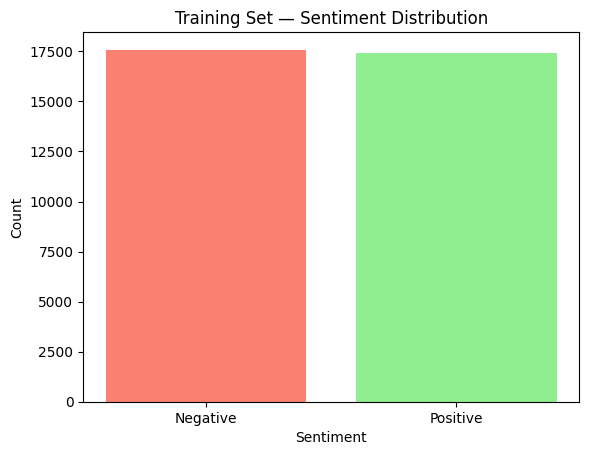

In [11]:
target_counts = Counter(train_df['sentiment'])
print("Sentiment Distribution:", target_counts)
print(f"Class balance ratio (Negative:Positive): {target_counts[0] / target_counts[1]:.3f}")

plt.bar(target_counts.keys(), target_counts.values(), color=['salmon', 'lightgreen'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Training Set — Sentiment Distribution')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.show()

A bar chart with two bars — Negative (17,584) and Positive (17,416). Salmon and light-green colours. Short explanation: This confirms the training set is almost perfectly balanced (1.010 ratio), which means the model has equal exposure to both sentiment classes during training and accuracy is a fair evaluation metric. No class weighting needed.

In [12]:
negations = {'not', 'no', 'nor', 'never', 'none', 'neither'}
stop_words = set(stopwords.words('english')) - negations
lemmatizer = WordNetLemmatizer()

In [13]:
def preprocess_text(text):
    """
    Clean text following PDF guidelines:
    1. Lowercase
    2. Remove HTML tags (IMDb-specific)
    3. Remove URLs
    4. Remove mentions and hashtags
    5. Expand contractions
    6. Remove punctuation and numbers
    7. Remove stopwords (preserving negations) + lemmatize
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Remove HTML tags (IMDb has <br />)
    text = re.sub(r'<[^>]+>', ' ', text)

    # 3. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 4. Remove mentions and hashtags
    text = re.sub(r'\@\w+|\#', '', text)

    # 5. Expand contractions (PDF requirement)
    contractions = {
        "don't": "do not", "doesn't": "does not", "didn't": "did not",
        "won't": "will not", "wouldn't": "would not", "shouldn't": "should not",
        "couldn't": "could not", "can't": "cannot", "isn't": "is not",
        "aren't": "are not", "wasn't": "was not", "weren't": "were not",
        "haven't": "have not", "hasn't": "has not", "i'm": "i am",
        "you're": "you are", "it's": "it is", "that's": "that is",
        "n't": " not"
    }
    for c, e in contractions.items():
        text = text.replace(c, e)

    # 6. Remove punctuation and numbers
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # 7. Remove stopwords (negations preserved) and lemmatize
    negations = {'not', 'no', 'nor', 'never', 'none', 'neither'}
    stop_words = set(stopwords.words('english')) - negations
    lemmatizer = WordNetLemmatizer()
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Test
sample = train_df['review'].iloc[1]
cleaned = preprocess_text(sample)
print("Original_Text:", sample[:200])
print("\nCleaned Text :", cleaned[:200])

Original_Text: With this movie I was really hoping that the idea was to make up for the hashed together ineptitude of the first AVP, and yet to my horror: Requiem is far worse than I could have imagined.<br /><br />

Cleaned Text : movie really hoping idea make hashed together ineptitude first avp yet horror requiem far worse could imagined hope opening moment film inside predator ship almost breathed sigh relief finally saw pre


In [14]:
print("Cleaning Train Test and Valid")
train_df['cleaned_text'] = train_df['review'].apply(preprocess_text)
val_df['cleaned_text'] = val_df['review'].apply(preprocess_text)
test_df['cleaned_text'] = test_df['review'].apply(preprocess_text)

print("\nDone! Sample comparison:")
print(f"Original: {train_df['review'].iloc[0][:200]}")
print(f"Cleaned : {train_df['cleaned_text'].iloc[0][:200]}")

Cleaning Train Test and Valid

Done! Sample comparison:
Original: Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -
Cleaned : avoided seeing movie cinema buying dvd wife xmas watch not expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical rac


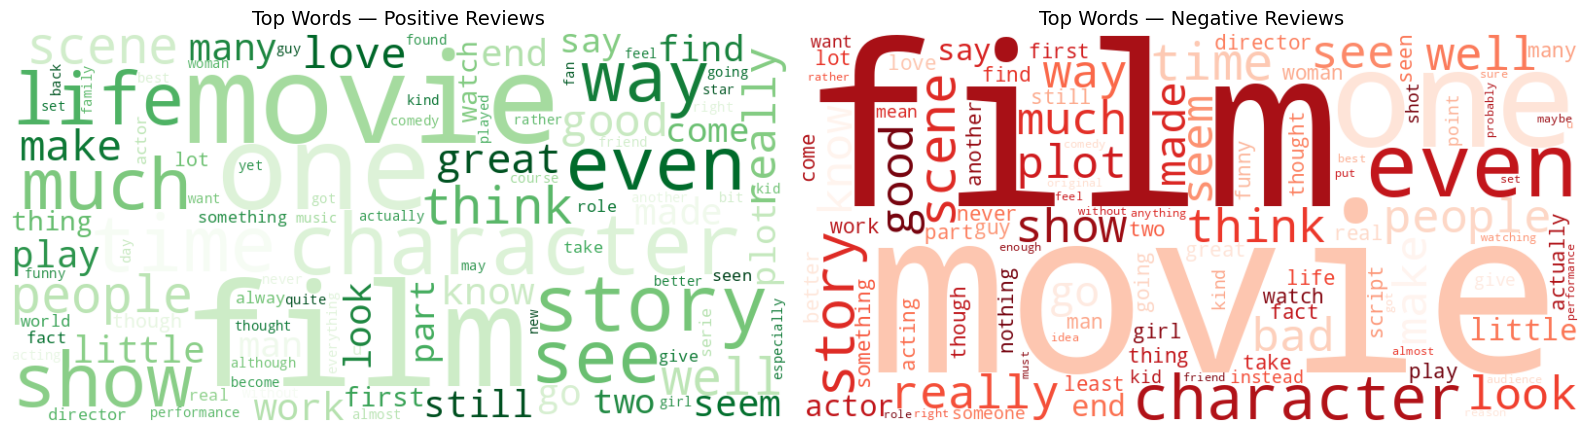

In [15]:
# Separate positive and negative reviews
pos_words = ' '.join(train_df[train_df['sentiment'] == 1]['cleaned_text'])
neg_words = ' '.join(train_df[train_df['sentiment'] == 0]['cleaned_text'])

# Generate word clouds
wc_pos = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='Greens').generate(pos_words)
wc_neg = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='Reds').generate(neg_words)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Top Words — Positive Reviews', fontsize=14)

axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Top Words — Negative Reviews', fontsize=14)

plt.tight_layout()
plt.show()

Two side-by-side word clouds — green for positive reviews, red for negative reviews. Larger words appear more frequently. Short explanation: A quick sanity check that preprocessing produced clean, sentiment-bearing tokens. Positive cloud should show "great", "love", "best", "amazing"; negative cloud should show "bad", "boring", "worst", "terrible". Confirms the cleaning pipeline didn't strip away meaningful signal.

In [16]:
# Sample demonstration first (tutor's style)
sample_texts = [
    "This film was an absolute masterpiece.",
    "Boring story and terrible acting.",
    "Loved every minute of it.",
    "Could have been better, honestly.",
    "One of the best movies I have seen."
]

demo_tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
demo_tokenizer.fit_on_texts(sample_texts)
demo_sequences = demo_tokenizer.texts_to_sequences(sample_texts)

print("Demo Word Index:", demo_tokenizer.word_index)
print("Demo Sequences :", demo_sequences)

Demo Word Index: {'<OOV>': 1, 'of': 2, 'have': 3, 'this': 4, 'film': 5, 'was': 6, 'an': 7, 'absolute': 8, 'masterpiece': 9, 'boring': 10, 'story': 11, 'and': 12, 'terrible': 13, 'acting': 14, 'loved': 15, 'every': 16, 'minute': 17, 'it': 18, 'could': 19, 'been': 20, 'better': 21, 'honestly': 22, 'one': 23, 'the': 24, 'best': 25, 'movies': 26, 'i': 27, 'seen': 28}
Demo Sequences : [[4, 5, 6, 7, 8, 9], [10, 11, 12, 13, 14], [15, 16, 17, 2, 18], [19, 3, 20, 21, 22], [23, 2, 24, 25, 26, 27, 3, 28]]


In [17]:
# Fit tokenizer on training data only
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['cleaned_text'])

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(train_df['cleaned_text'])
X_val_seq   = tokenizer.texts_to_sequences(val_df['cleaned_text'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['cleaned_text'])

print(f"Total vocabulary size : {len(tokenizer.word_index)}")
print(f"Sample sequence length: {len(X_train_seq[100])}")

Total vocabulary size : 122386
Sample sequence length: 40


In [18]:
# Sequence length statistics
seq_lengths = [len(seq) for seq in X_train_seq]

print("Sequence length stats:")
print(f"  Min    : {np.min(seq_lengths)}")
print(f"  Max    : {np.max(seq_lengths)}")
print(f"  Mean   : {np.mean(seq_lengths):.0f}")
print(f"  Median : {np.median(seq_lengths):.0f}")
print(f"  95th % : {np.percentile(seq_lengths, 95):.0f}")
print(f"  99th % : {np.percentile(seq_lengths, 99):.0f}")

# Use 95th percentile for padding length
max_len = int(np.percentile(seq_lengths, 95))
print(f"\nPadding length chosen: {max_len}")

# Pad all splits to the same length
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

# Labels as numpy arrays
y_train = np.array(train_df['sentiment'])
y_val   = np.array(val_df['sentiment'])
y_test  = np.array(test_df['sentiment'])

print(f"\nShapes:")
print(f"  X_train_pad: {X_train_pad.shape}")
print(f"  X_val_pad  : {X_val_pad.shape}")
print(f"  X_test_pad : {X_test_pad.shape}")

Sequence length stats:
  Min    : 4
  Max    : 1433
  Mean   : 120
  Median : 90
  95th % : 309
  99th % : 467

Padding length chosen: 309

Shapes:
  X_train_pad: (35000, 309)
  X_val_pad  : (5000, 309)
  X_test_pad : (10000, 309)


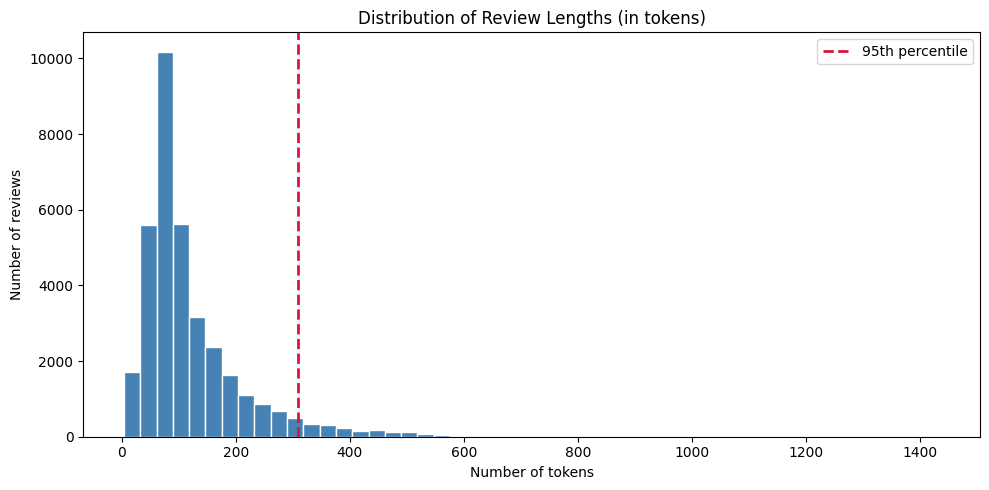

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(seq_lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.percentile(seq_lengths, 95), color='crimson',
            linestyle='--', linewidth=2, label='95th percentile')
plt.title('Distribution of Review Lengths (in tokens)')
plt.xlabel('Number of tokens')
plt.ylabel('Number of reviews')
plt.legend()
plt.tight_layout()
plt.show()

A histogram of review lengths in tokens (steel blue bars), with a crimson dashed line marking the 95th percentile at 309 tokens. Short explanation: Most reviews are short (median 90 tokens), but a long tail stretches to 1,433 tokens. Padding to 309 (the 95th percentile) keeps 95% of all content while saving memory and compute compared to padding to the full max length.

In [20]:
# Check class balance across splits
train_counts = Counter(y_train)
val_counts   = Counter(y_val)
test_counts  = Counter(y_test)

print("Class distribution:")
print(f"  Train : Neg: {train_counts[0]}, Pos: {train_counts[1]}")
print(f"  Val   : Neg: {val_counts[0]}, Pos: {val_counts[1]}")
print(f"  Test  : Neg: {test_counts[0]}, Pos: {test_counts[1]}")

# How many test tokens fell into <OOV>?
oov_idx = tokenizer.word_index.get("<OOV>", 1)
total_tokens = X_test_pad[X_test_pad != 0].size
oov_tokens   = (X_test_pad == oov_idx).sum()

print(f"\nOOV rate on test set: {oov_tokens/total_tokens*100:.2f}% "
      f"({oov_tokens}/{total_tokens} tokens)")

Class distribution:
  Train : Neg: 17584, Pos: 17416
  Val   : Neg: 2455, Pos: 2545
  Test  : Neg: 4961, Pos: 5039

OOV rate on test set: 5.41% (62789/1161029 tokens)


In [21]:
# Hyperparameters
vocab_size    = len(tokenizer.word_index) + 1
embedding_dim = 128
hidden_units  = 64

print("Building Model 1: Simple RNN")

model_rnn = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(hidden_units),
    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_rnn.summary()

Building Model 1: Simple RNN


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 309, 128)       │    15,665,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,677,953 (59.81 MB)

 Trainable params: 15,677,953 (59.81 MB)

 Non-trainable params: 0 (0.00 B)

A text table listing each layer of the Simple RNN — Input → Embedding → SimpleRNN → Dense, with output shapes and parameter counts. Total params ~15.7M. Short explanation: Documents the exact architecture used as the baseline. The Embedding layer dominates parameter count because vocab is 122,387 × 128 dimensions.

In [22]:
print("Building Model 2: LSTM")

model_lstm = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(hidden_units),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

Building Model 2: LSTM


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 309, 128)       │    15,665,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,715,009 (59.95 MB)

 Trainable params: 15,715,009 (59.95 MB)

 Non-trainable params: 0 (0.00 B)

Same architecture as Figure 4 but with LSTM replacing SimpleRNN. LSTM layer has ~4× more parameters than SimpleRNN due to the four gating mechanisms. Short explanation: Identical to Model 1 except for the recurrent layer. This isolates the effect of gating since everything else (embedding dim, hidden size, training procedure) is matched.

In [23]:
# Callbacks for Simple RNN
checkpoint_rnn = ModelCheckpoint('rnn_best_model.keras',
                                 monitor='val_loss',
                                 save_best_only=True,
                                 verbose=1)

early_stop = EarlyStopping(monitor='val_loss',
                           patience=4,
                           restore_best_weights=True,
                           verbose=1)

# Train Simple RNN
history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[checkpoint_rnn, early_stop]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4997 - loss: 0.6970
Epoch 1: val_loss improved from None to 0.69611, saving model to rnn_best_model.keras

Epoch 1: finished saving model to rnn_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 35s 29ms/step - accuracy: 0.5018 - loss: 0.6962 - val_accuracy: 0.4840 - val_loss: 0.6961
Epoch 2/10
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4999 - loss: 0.6955
Epoch 2: val_loss improved from 0.69611 to 0.69494, saving model to rnn_best_model.keras

Epoch 2: finished saving model to rnn_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 29s 26ms/step - accuracy: 0.5025 - loss: 0.6950 - val_accuracy: 0.5062 - val_loss: 0.6949
Epoch 3/10
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5113 - loss: 0.6931
Epoch 3: val_loss improved from 0.69494 to 0.69284, saving model to rnn_best_model.keras

Epoch 3: finished saving model to rnn_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.

In [24]:
def model_diagnosis(model, history, X_test_pad, y_test, model_name="Model"):
    """Run full evaluation on a trained model: scores, threshold sweep,
    accuracy, classification report, confusion matrix, and history plots."""

    y_pred_proba = model.predict(X_test_pad, verbose=1)
    y_pred = (y_pred_proba > 0.5).astype("int32").flatten()

    print(f"\n--- Diagnosis: {model_name} ---")

    # Prediction score distribution
    print("\nPrediction score stats:")
    print(f"  min  : {y_pred_proba.min():.4f}")
    print(f"  max  : {y_pred_proba.max():.4f}")
    print(f"  mean : {y_pred_proba.mean():.4f}")
    print(f"  std  : {y_pred_proba.std():.4f}")

    # Threshold sweep
    print("\nThreshold sweep:")
    print(f"  {'Threshold':<12}{'Pred Pos%':<12}{'Pred Neg%':<12}")
    for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
        pp = (y_pred_proba > t).mean() * 100
        print(f"  {t:<12.1f}{pp:<12.1f}{100-pp:<12.1f}")

    # Accuracy + report
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {accuracy:.4f}\n")

    print("Classification report:")
    print(classification_report(y_test, y_pred,
                                target_names=["Negative", "Positive"],
                                zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion matrix:")
    print(f"            Pred Neg   Pred Pos")
    print(f"True Neg     {cm[0,0]:<10} {cm[0,1]}")
    print(f"True Pos     {cm[1,0]:<10} {cm[1,1]}")

    # Training history plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ["loss", "accuracy"]):
        ax.plot(history.history[metric], label="train")
        ax.plot(history.history[f"val_{metric}"], label="val")
        ax.set_title(f"{model_name} — {metric}")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = f'{model_name.lower().replace(" ", "_")}_curves.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

--- Diagnosis: Simple RNN ---

Prediction score stats:
  min  : 0.4507
  max  : 0.5906
  mean : 0.5035
  std  : 0.0264

Threshold sweep:
  Threshold   Pred Pos%   Pred Neg%   
  0.3         100.0       0.0         
  0.4         100.0       0.0         
  0.5         65.9        34.1        
  0.6         0.0         100.0       
  0.7         0.0         100.0       

Accuracy: 0.5015

Classification report:
              precision    recall  f1-score   support

    Negative       0.50      0.34      0.40      4961
    Positive       0.50      0.66      0.57      5039

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.50      0.50      0.49     10000

Confusion matrix:
            Pred Neg   Pred Pos
True Neg     1695       3266
True Pos     1719       3320


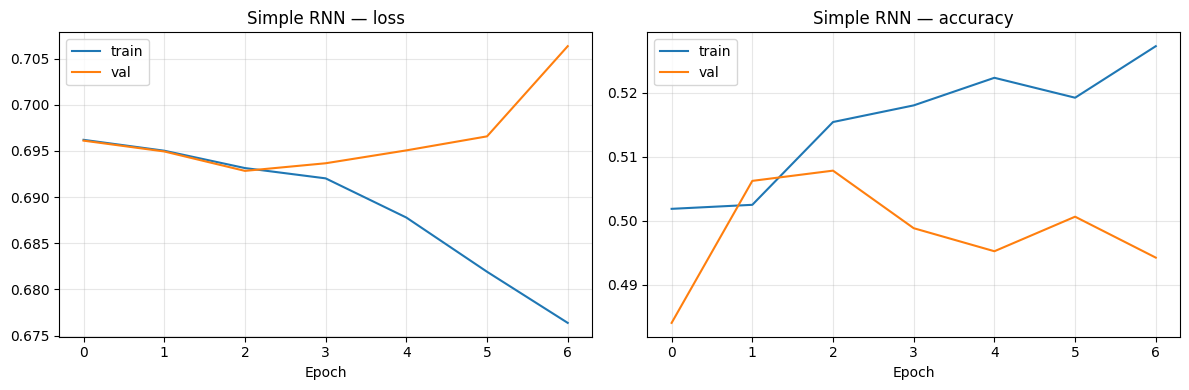

In [25]:
# Evaluate Simple RNN on test set
acc_rnn = model_diagnosis(model_rnn, history_rnn, X_test_pad, y_test, "Simple RNN")

In [26]:
# Callbacks for LSTM
checkpoint_lstm = ModelCheckpoint('lstm_best_model.keras',
                                  monitor='val_loss',
                                  save_best_only=True,
                                  verbose=1)
early_stop = EarlyStopping(monitor='val_loss',
                           patience=4,
                           restore_best_weights=True,
                           verbose=1)

# Train LSTM
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[checkpoint_lstm, early_stop]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4981 - loss: 0.6935
Epoch 1: val_loss improved from None to 0.69262, saving model to lstm_best_model.keras

Epoch 1: finished saving model to lstm_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 31s 24ms/step - accuracy: 0.5000 - loss: 0.6930 - val_accuracy: 0.4974 - val_loss: 0.6926
Epoch 2/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5211 - loss: 0.6835
Epoch 2: val_loss improved from 0.69262 to 0.69227, saving model to lstm_best_model.keras

Epoch 2: finished saving model to lstm_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - accuracy: 0.5207 - loss: 0.6824 - val_accuracy: 0.5018 - val_loss: 0.6923
Epoch 3/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7400 - loss: 0.4922
Epoch 3: val_loss improved from 0.69227 to 0.32855, saving model to lstm_best_model.keras

Epoch 3: finished saving model to lstm_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - accura

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

--- Diagnosis: LSTM ---

Prediction score stats:
  min  : 0.0012
  max  : 0.9992
  mean : 0.5003
  std  : 0.4392

Threshold sweep:
  Threshold   Pred Pos%   Pred Neg%   
  0.3         53.6        46.4        
  0.4         51.7        48.3        
  0.5         50.2        49.8        
  0.6         48.9        51.1        
  0.7         47.0        53.0        

Accuracy: 0.8830

Classification report:
              precision    recall  f1-score   support

    Negative       0.88      0.88      0.88      4961
    Positive       0.89      0.88      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Confusion matrix:
            Pred Neg   Pred Pos
True Neg     4386       575
True Pos     595        4444


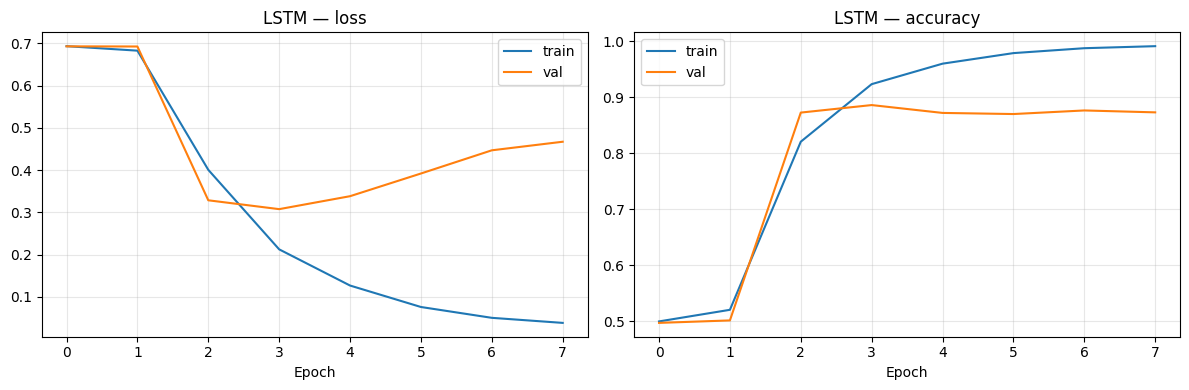

In [27]:
# Evaluate LSTM on test set
acc_lstm = model_diagnosis(model_lstm, history_lstm, X_test_pad, y_test, "LSTM")

In [28]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 61.5 MB/s eta 0:00:00


In [29]:

import gensim.downloader as api
from gensim.models import KeyedVectors

# Load pretrained GloVe embeddings
print("Loading pretrained embeddings...")
word2vec_model = api.load("glove-wiki-gigaword-100")
print(f"Loaded! {len(word2vec_model)} words available")

Loading pretrained embeddings...
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded! 400000 words available


In [30]:
embedding_dim_w2v = 100   # matches glove-wiki-gigaword-100

# Build embedding matrix from pretrained vectors
embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))
hit, miss = 0, 0

for word, index in tokenizer.word_index.items():
    if index >= vocab_size:
        continue
    if word in word2vec_model:
        embedding_matrix[index] = word2vec_model[word]
        hit += 1
    else:
        # Random init for OOV words
        embedding_matrix[index] = np.random.normal(scale=0.6, size=(embedding_dim_w2v,))
        miss += 1

print(f"Found in GloVe : {hit}")
print(f"Missing (random): {miss}")
print(f"Coverage       : {hit/(hit+miss)*100:.1f}%")
print(f"Matrix shape   : {embedding_matrix.shape}")

# Free up memory
import gc
del word2vec_model
gc.collect()
print("\nGloVe model unloaded from memory")

Found in GloVe : 60037
Missing (random): 62349
Coverage       : 49.1%
Matrix shape   : (122387, 100)

GloVe model unloaded from memory


In [31]:
print("Building Model 3: LSTM with pretrained GloVe embeddings")

model_lstm_w2v = Sequential([
    Input(shape=(max_len,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        trainable=False                # keep pretrained weights frozen
    ),
    LSTM(hidden_units),
    Dense(1, activation='sigmoid')
])

model_lstm_w2v.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm_w2v.summary()

Building Model 3: LSTM with pretrained GloVe embeddings


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 309, 100)       │    12,238,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,281,005 (46.85 MB)

 Trainable params: 42,305 (165.25 KB)

 Non-trainable params: 12,238,700 (46.69 MB)

In [32]:
# Callbacks for LSTM + GloVe
checkpoint_w2v = ModelCheckpoint('lstm_w2v_best_model.keras',
                                 monitor='val_loss',
                                 save_best_only=True,
                                 verbose=1)

early_stop = EarlyStopping(monitor='val_loss',
                           patience=4,
                           restore_best_weights=True,
                           verbose=1)

# Train LSTM with frozen GloVe embeddings
history_lstm_w2v = model_lstm_w2v.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[checkpoint_w2v, early_stop]
)

Epoch 1/10
1091/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.5120 - loss: 0.6906
Epoch 1: val_loss improved from None to 0.62627, saving model to lstm_w2v_best_model.keras

Epoch 1: finished saving model to lstm_w2v_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 31s 27ms/step - accuracy: 0.5410 - loss: 0.6825 - val_accuracy: 0.6664 - val_loss: 0.6263
Epoch 2/10
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5281 - loss: 0.6862
Epoch 2: val_loss did not improve from 0.62627
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.5097 - loss: 0.6911 - val_accuracy: 0.5104 - val_loss: 0.6925
Epoch 3/10
1092/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5140 - loss: 0.6906
Epoch 3: val_loss did not improve from 0.62627
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.5246 - loss: 0.6884 - val_accuracy: 0.5126 - val_loss: 0.6912
Epoch 4/10
1090/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5599 - loss: 0.6732
Epoch 4: val_loss did not improve f

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

--- Diagnosis: LSTM + Word2Vec ---

Prediction score stats:
  min  : 0.1627
  max  : 0.6910
  mean : 0.4609
  std  : 0.1639

Threshold sweep:
  Threshold   Pred Pos%   Pred Neg%   
  0.3         77.0        23.0        
  0.4         76.4        23.6        
  0.5         75.8        24.2        
  0.6         1.4         98.6        
  0.7         0.0         100.0       

Accuracy: 0.6514

Classification report:
              precision    recall  f1-score   support

    Negative       0.80      0.39      0.53      4961
    Positive       0.60      0.91      0.72      5039

    accuracy                           0.65     10000
   macro avg       0.70      0.65      0.63     10000
weighted avg       0.70      0.65      0.63     10000

Confusion matrix:
            Pred Neg   Pred Pos
True Neg     1949       3012
True Pos     474        4565


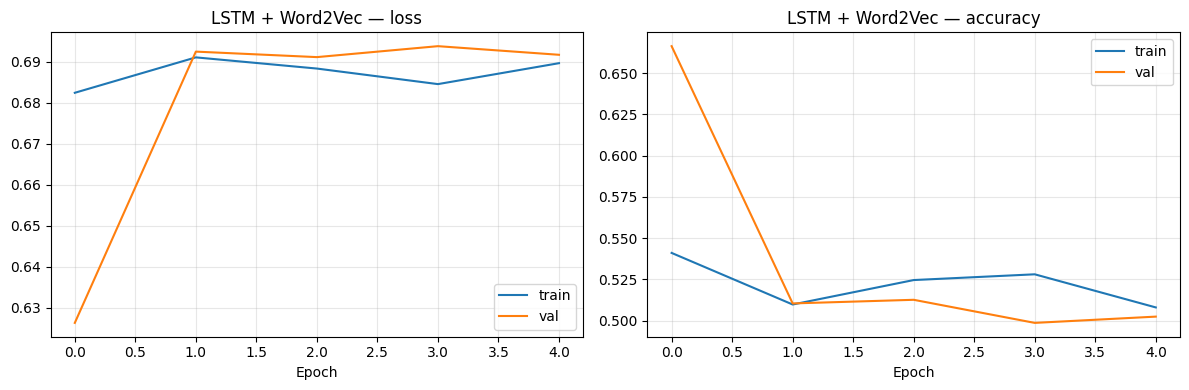

In [33]:
# Evaluate LSTM + GloVe on test set
acc_w2v = model_diagnosis(model_lstm_w2v, history_lstm_w2v, X_test_pad, y_test, "LSTM + Word2Vec")

Final Model Comparison
          Model Accuracy
     Simple RNN   0.5015
           LSTM   0.8830
LSTM + Word2Vec   0.6514


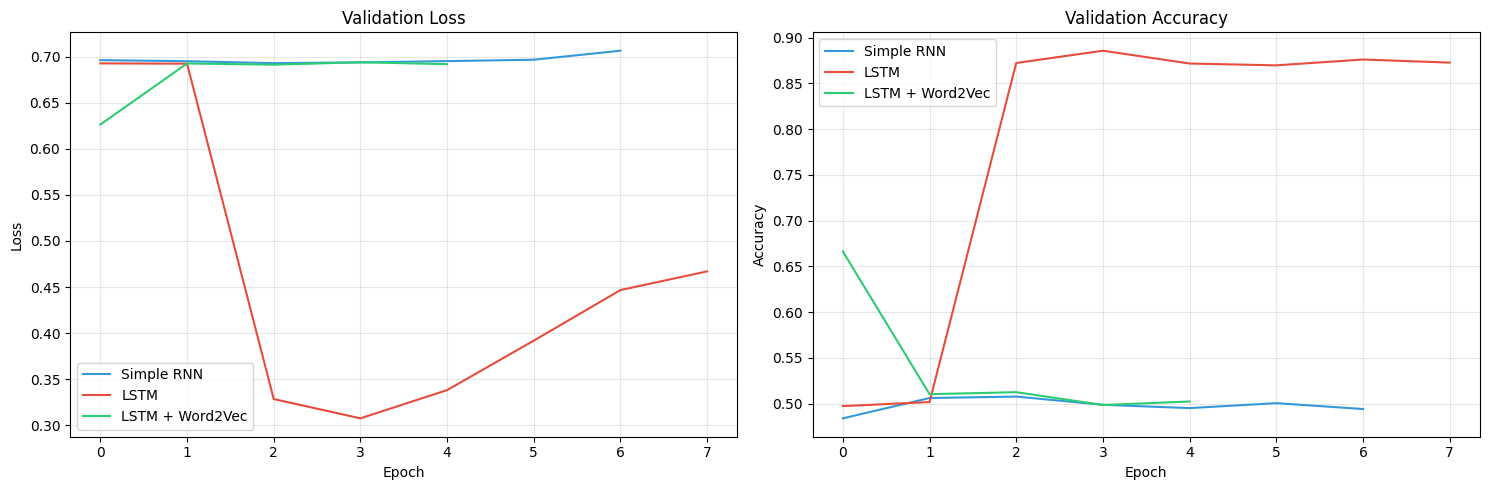

In [34]:
# Build the comparison table
comparison_df = pd.DataFrame({
    'Model'   : ['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
    'Accuracy': [f'{acc_rnn:.4f}', f'{acc_lstm:.4f}', f'{acc_w2v:.4f}']
})

print("Final Model Comparison")
print(comparison_df.to_string(index=False))

# Plot validation curves side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Validation loss
axes[0].plot(history_rnn.history['val_loss'],      label='Simple RNN',      color='#3498db')
axes[0].plot(history_lstm.history['val_loss'],     label='LSTM',            color='#e74c3c')
axes[0].plot(history_lstm_w2v.history['val_loss'], label='LSTM + Word2Vec', color='#2ecc71')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation accuracy
axes[1].plot(history_rnn.history['val_accuracy'],      label='Simple RNN',      color='#3498db')
axes[1].plot(history_lstm.history['val_accuracy'],     label='LSTM',            color='#e74c3c')
axes[1].plot(history_lstm_w2v.history['val_accuracy'], label='LSTM + Word2Vec', color='#2ecc71')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
# Use the best model (LSTM) for error analysis since it had highest accuracy
y_pred_proba = model_lstm.predict(X_test_pad, verbose=0)
y_pred = (y_pred_proba > 0.5).astype("int32").flatten()

# Find misclassified samples
misclassified_idx = np.where(y_pred != y_test)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test)} "
      f"({len(misclassified_idx)/len(y_test)*100:.2f}%)")

# Show 3 misclassified examples for the report
print("Misclassified Examples — Error Analysis")

for i, idx in enumerate(misclassified_idx[:3], 1):
    true_label = "Positive" if y_test[idx] == 1 else "Negative"
    pred_label = "Positive" if y_pred[idx] == 1 else "Negative"
    confidence = y_pred_proba[idx][0]

    print(f"\nExample {i}")
    print(f"  True       : {true_label}")
    print(f"  Predicted  : {pred_label} (confidence: {confidence:.4f})")
    print(f"  Review     : {test_df['review'].iloc[idx][:300]}")
    print(f"  Cleaned    : {test_df['cleaned_text'].iloc[idx][:300]}")

Total misclassified: 1170 / 10000 (11.70%)
Misclassified Examples — Error Analysis

Example 1
  True       : Positive
  Predicted  : Negative (confidence: 0.0384)
  Review     : I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok 
  Cleaned    : really liked summerslam due look arena curtain look overall interesting reason anyways could one best summerslams ever wwf not lex luger main event yokozuna time ok huge fat man v strong man glad time changed terrible main event like every match luger terrible match card razor ramon v ted dibiase st

Example 2
  True       : Positive
  Predicted  : Negative (confidence: 0.0313)
  Review     : Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like something signifi

In [36]:
def predict_sentiment(text, model):
    cleaned = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob = model.predict(padded, verbose=0)[0][0]

    if prob > 0.5:
        return "Positive", float(prob)
    else:
        return "Negative", float(1 - prob)

# few sample reviews
test_reviews = [
    "This movie was absolutely amazing! Great acting and storyline.",
    "Worst film I have ever seen. Total waste of time.",
    "It was okay, nothing special but not terrible either."
]

print("Sample predictions (using best model — LSTM):\n")
for review in test_reviews:
    sentiment, confidence = predict_sentiment(review, model_lstm)
    print(f"Review : {review[:80]}")
    print(f"Result : {sentiment} ({confidence:.4f} confidence)\n")

Sample predictions (using best model — LSTM):

Review : This movie was absolutely amazing! Great acting and storyline.
Result : Positive (0.9622 confidence)

Review : Worst film I have ever seen. Total waste of time.
Result : Negative (0.9796 confidence)

Review : It was okay, nothing special but not terrible either.
Result : Negative (0.9352 confidence)

